## Real Estate Dataset Inconsistency Analysis (2000–2025)

**Course:** DATA 3960 – Data Analytics Capstone  
**Prepared by:** Group 1

**Role:** Data Cleaning & Integration Lead  

### Business Understanding & Data Preparation


### Step 1: Objective & Problem Statement

### Objective
We want to help real estate agents and sellers in Edmonton know upfront if a property is likely to stay on the market for too long (over 60 days) so they can price it correctly and sell faster.

### Problem Statement
Many homes in Edmonton stay unsold for months. Sellers often expect higher prices than buyers are willing to pay. This mismatch is called the Expectation Gap and it creates stale listings, lost opportunities, and frustration.

### Key Research Questions
- Can we predict whether a new listing will remain unsold for more than 60 days?
- How does pricing relative to neighborhood sold prices impact time on market?
- Which factors (price gap, property features, location, or socio-economic indicators) most strongly influence listing staleness?

### Business Insight Angle
We’re not just predicting stale listings. We’re giving actionable insights:
- “This house is overpriced for this neighborhood.”
- “Properties here sell faster in summer.”
- “High-income, growing-family areas respond better to smaller price gaps.”


In [3]:
# ==========================================
# Step 1: Load Datasets for Analysis
# ==========================================

# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define base path for datasets
base_path = r"C:\Users\Adewale Sam\Desktop\DATA3960 - Data Analytics Capstone"

# Load Active listings
active_df = pd.read_csv(f"{base_path}\\RealEstateDataJanuary2026-Data3960-Active.csv",
                        encoding='cp1252', low_memory=False)

# Load Sold listings
sold_df = pd.read_csv(f"{base_path}\\RealEstateDataJanuary2026-Data3960-sold.csv",
                      encoding='cp1252', low_memory=False)

# Print confirmation
print("✅ Datasets loaded successfully.")
print(f"Active listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")

# Preview first 5 rows of each dataset
print("\n--- Active Listings Preview ---")
display(active_df.head())

print("\n--- Sold Listings Preview ---")
display(sold_df.head())

# Check for missing values
print("\n--- Active Listings Missing Values ---")
print(active_df.isnull().sum())

print("\n--- Sold Listings Missing Values ---")
print(sold_df.isnull().sum())

# Quick descriptive statistics
print("\n--- Active Listings Summary ---")
display(active_df.describe())

print("\n--- Sold Listings Summary ---")
display(sold_df.describe())


✅ Datasets loaded successfully.
Active listings shape: (705506, 45)
Sold listings shape: (515122, 48)

--- Active Listings Preview ---


,Linc #,Prop Class,Area/City,Community,Address,Status,List Price,Postal Code,Sold Date,Sold Price,...,Bsmt Dev,Garage Y/N,Price,Buyer Firm 1 - Office Name,Listing Firm 1 - Office Name,Legal Block,Legal Lot,Lot Sq Metres,Legal Plan,ActiveMonth
0,13103346.0,VLOT,Abee,Abee,4801 50 Street,A,40000,T0A 0A0,NaN,0,...,NaN,NaN,40000,NaN,Muller Realty Inc,.,C,557.00,2722HW,2021-01-31
1,13103346.0,VLOT,Abee,Abee,4801 50 Street,A,40000,T0A 0A0,NaN,0,...,NaN,NaN,40000,NaN,Muller Realty Inc,.,C,557.00,2722HW,2021-02-28
2,13103346.0,VLOT,Abee,Abee,48 50 Street,A,39900,T0A 0A0,NaN,0,...,NaN,NaN,39900,NaN,Muller Realty Inc,.,C,526.09,2722HW,2021-08-31
3,13103346.0,VLOT,Abee,Abee,48 50 Street,A,39900,T0A 0A0,NaN,0,...,NaN,NaN,39900,NaN,Muller Realty Inc,.,C,526.09,2722HW,2021-06-30
4,13103346.0,VLOT,Abee,Abee,48 50 Street,A,39900,T0A 0A0,NaN,0,...,NaN,NaN,39900,NaN,Muller Realty Inc,.,C,526.09,2722HW,2021-07-31



--- Sold Listings Preview ---


,Linc #,Prop Class,Area/City,Community,Address,Status,List Price,Postal Code,Sold Date,Sold Price,...,Price Per SQFT,Sold Pr / List Pr Ratio,Price,Sold Price/Sq Ft,Buyer Firm 1 - Office Name,Listing Firm 1 - Office Name,Legal Block,Legal Lot,Lot Sq Metres,Legal Plan
0,23384076,VLOT,Abee,Abee,48 50 Street,S,30000,T0A 0A0,2016-08-31,21000,...,0.00,70.00,21000,0.00,Muller Realty Inc,Muller Realty Inc,0,0,8874.0,0
1,0023390842,SF,Abee,Abee,4910 50 STREET,S,74900,T0A 0A0,2023-07-27,67000,...,98.83,89.45,67000,98.83,RE/MAX River City,Century 21 All Stars Realty Ltd,0,0,0.0,0
2,0023397698,SF,Abee,Abee,5002 50 Avenue,S,150000,T0A 0A0,2024-11-15,137000,...,104.97,91.33,137000,104.97,Royal LePage Noralta Real Estate,MaxWell Progressive,0,0,0.0,0
3,17665648,SF,Acme,NaN,805 CLARK Street,S,99900,T0M 0A0,2003-06-17,90000,...,90.00,90.09,90000,90.00,MLS NonMember Add Listing,MaxWell Polaris,21,2,0.0,7711559
4,17662727,SF,Acme,NaN,738 Clarke Street,S,209900,T0M 0A0,2009-04-22,203000,...,178.47,96.71,203000,178.47,REALTORSÂ® Association of Edmonton,Realty Executives Synergy,19,17,0.0,771559



--- Active Listings Missing Values ---
Linc #                               2
Prop Class                           0
Area/City                            0
Community                         7697
Address                              0
Status                               0
List Price                           0
Postal Code                          2
Sold Date                       704999
Sold Price                           0
Listing ID #                         0
DOM                                  0
FlrArea SF                           0
TotFlrArea                           0
Rooms AG                             0
Bedrms AG                            0
Beds                                 0
Full Baths                           0
Half Baths                           0
Baths                                0
Ensuite                              0
Yr Built                             0
Style                            41130
Front Exp                        29415
FrontageM               

,Linc #,List Price,Sold Price,DOM,FlrArea SF,TotFlrArea,Rooms AG,Bedrms AG,Beds,Full Baths,...,Baths,Yr Built,FrontageM,Encl Park,# Finished Levels,Cumulative DOM,Cumulative DOMLS,Days On MLS,Price,Lot Sq Metres
count,7.055040e+05,7.055060e+05,7.055060e+05,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,...,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,705506.000000,7.055060e+05,7.055060e+05
mean,7.653686e+07,4.520081e+05,2.627180e+02,88.236854,1384.905593,128.662066,5.624818,2.487538,2.991593,1.978496,...,2.028269,1879.287921,2.205936,0.605037,1.964692,131.144006,130.367460,89.209949,4.519959e+05,1.552050e+03
std,4.359105e+08,1.883288e+06,1.110582e+04,158.356783,801.286547,74.442028,2.185179,1.056799,1.415939,0.981506,...,0.993448,467.668806,177.271334,1.414767,0.968745,220.122768,218.558251,157.154053,1.883288e+06,5.949371e+04
min,0.000000e+00,3.000000e+03,0.000000e+00,-7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-9.000000,3.000000e+03,0.000000e+00
25%,1.630044e+07,2.250000e+05,0.000000e+00,21.000000,959.920000,89.180000,5.000000,2.000000,2.000000,1.000000,...,1.100000,1975.000000,0.000000,0.000000,1.000000,28.000000,27.000000,22.000000,2.250000e+05,0.000000e+00
50%,3.071292e+07,3.550000e+05,0.000000e+00,49.000000,1245.920000,115.750000,6.000000,3.000000,3.000000,2.000000,...,2.100000,2003.000000,0.000000,0.000000,2.000000,70.000000,69.000000,50.000000,3.550000e+05,1.097250e+02
75%,3.602892e+07,5.099000e+05,0.000000e+00,95.000000,1743.750000,162.000000,7.000000,3.000000,4.000000,2.000000,...,2.200000,2014.000000,0.000000,1.000000,3.000000,148.000000,148.000000,96.000000,5.099000e+05,4.773700e+02
max,1.000000e+10,5.419000e+08,2.100000e+06,4133.000000,52796.930000,4905.000000,15.000000,10.000000,10.000000,40.000000,...,40.000000,2025.000000,77661.000000,249.000000,9.000000,5431.000000,4633.000000,4438.000000,5.419000e+08,1.406640e+07



--- Sold Listings Summary ---


,List Price,Sold Price,DOM,FlrArea SF,TotFlrArea,Rooms AG,Bedrms AG,Beds,Full Baths,Half Baths,...,List Pr / SqFt,# Finished Levels,Cumulative DOM,Cumulative DOMLS,Days On MLS,Price Per SQFT,Sold Pr / List Pr Ratio,Price,Sold Price/Sq Ft,Lot Sq Metres
count,5.151220e+05,5.151220e+05,515122.000000,515122.000000,515122.000000,515122.000000,515122.000000,515122.000000,515122.000000,515122.000000,...,515122.000000,515122.000000,515122.000000,515122.00000,515122.000000,515122.000000,515122.000000,5.151220e+05,515122.000000,5.151220e+05
mean,3.309385e+05,3.230199e+05,50.070560,1335.492803,124.071462,5.654505,2.590330,3.181567,1.943773,0.526464,...,236.782424,2.003481,73.545199,69.22524,48.127886,231.561527,97.573817,3.237859e+05,231.107709,1.350367e+03
std,1.961602e+05,1.888999e+05,59.148579,567.267148,52.700892,1.722566,0.856551,1.117317,0.782452,0.642229,...,98.172945,0.856584,384.784315,224.30949,68.454769,339.736864,136.505415,5.814442e+05,96.586206,7.407945e+05
min,1.000000e+03,1.000000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,8.330000,1.000000e+03,0.000000,0.000000e+00
25%,1.995000e+05,1.925000e+05,16.000000,1022.570000,95.000000,5.000000,2.000000,3.000000,1.000000,0.000000,...,173.210000,1.000000,17.000000,15.00000,14.000000,167.800000,96.080000,1.925000e+05,167.800000,0.000000e+00
50%,3.146745e+05,3.050000e+05,32.000000,1219.550000,113.300000,6.000000,3.000000,3.000000,2.000000,0.000000,...,241.900000,2.000000,37.000000,35.00000,30.000000,236.030000,97.720000,3.050000e+05,236.030000,7.410000e+01
75%,4.195000e+05,4.100000e+05,65.000000,1588.210000,147.550000,6.000000,3.000000,4.000000,2.000000,1.000000,...,293.330000,2.000000,83.000000,81.00000,63.000000,287.330000,99.040000,4.100000e+05,287.330000,4.600775e+02
max,2.500000e+07,1.840000e+07,4154.000000,47361.160000,4400.000000,99.000000,10.000000,10.000000,41.000000,196.000000,...,2955.250000,9.000000,42781.000000,26700.00000,26700.000000,234005.460000,98014.890000,3.950000e+08,2913.630000,5.316580e+08



#### 1b: Data Preparation & Feature Engineering


In this step, we prepare the active listings dataset to answer our research questions:

1. Compute the average sold price per neighborhood to understand typical pricing.
2. Merge the neighborhood average price into the active listings dataset.
3. Calculate the Expectation Gap (% difference between listing price and neighborhood average).
4. Label listings as "stale" if they have been on the market for more than 60 days.
5. Generate summary statistics to inspect the relationship between pricing and staleness.



In [22]:
# Clean column names for easier access
active_df.columns = active_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
sold_df.columns = sold_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

# Filter for Edmonton
active_df = active_df[active_df['area_city'] == 'Edmonton'].copy()
sold_df = sold_df[sold_df['area_city'] == 'Edmonton'].copy()


In [23]:
# -----------------------------
# Data Preparation & Feature Engineering
# -----------------------------


import pandas as pd
import numpy as np

# -----------------------------
# 1️⃣ Load datasets
# -----------------------------
base_path = r"C:\Users\Adewale Sam\Desktop\DATA3960 - Data Analytics Capstone"

# Active listings
active_df = pd.read_csv(f"{base_path}\\RealEstateDataJanuary2026-Data3960-Active.csv",
                        encoding='cp1252', low_memory=False)

# Sold listings
sold_df = pd.read_csv(f"{base_path}\\RealEstateDataJanuary2026-Data3960-sold.csv",
                      encoding='cp1252', low_memory=False)

print("✅ Datasets loaded successfully")
print(f"Active listings shape: {active_df.shape}")
print(f"Sold listings shape: {sold_df.shape}")

# -----------------------------
# 2️⃣ Clean column names
# -----------------------------
active_df.columns = active_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
sold_df.columns = sold_df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')

# -----------------------------
# 3️⃣ Filter for Edmonton only
# -----------------------------
active_df = active_df[active_df['area_city'] == 'Edmonton'].copy()
sold_df = sold_df[sold_df['area_city'] == 'Edmonton'].copy()

print("✅ Filtered datasets for Edmonton only")
print(f"Active listings shape (Edmonton): {active_df.shape}")
print(f"Sold listings shape (Edmonton): {sold_df.shape}")

# -----------------------------
# 4️⃣ Compute average sold price per neighborhood
# -----------------------------
neighborhood_avg_price = sold_df.groupby('community')['list_price'].mean().reset_index()
neighborhood_avg_price.rename(columns={'list_price': 'avg_sold_price'}, inplace=True)

# -----------------------------
# 5️⃣ Merge average sold price into active listings
# -----------------------------
active_df = active_df.merge(neighborhood_avg_price, on='community', how='left')

# -----------------------------
# 6️⃣ Calculate Expectation Gap (%)
# -----------------------------
active_df['expectation_gap_percent'] = ((active_df['list_price'] - active_df['avg_sold_price'])
                                       / active_df['avg_sold_price']) * 100

# -----------------------------
# 7️⃣ Label stale listings (>60 days)
# -----------------------------
active_df['is_stale'] = np.where(active_df['days_on_mls'] > 60, 1, 0)

# -----------------------------
# 8️⃣ Quick summary statistics
# -----------------------------
summary = active_df.groupby('is_stale')['expectation_gap_percent'].describe()
print("\n✅ Expectation Gap summary by staleness (Edmonton only):\n", summary)

# -----------------------------
# 9️⃣ Preview first 5 rows
# -----------------------------
print("\n--- First 5 Edmonton Active Listings ---")
print(active_df[['list_price', 'avg_sold_price', 'expectation_gap_percent', 'days_on_mls', 'is_stale']].head())

print("\n--- Sold Listings Preview ---")
print(sold_df.head())

# -----------------------------
# 10️⃣ Check for missing values
# -----------------------------
print("\n--- Active Listings Missing Values ---")
print(active_df.isnull().sum())

print("\n--- Sold Listings Missing Values ---")
print(sold_df.isnull().sum())

# -----------------------------
# 11️⃣ Descriptive statistics
# -----------------------------
print("\n--- Active Listings Summary ---")
print(active_df.describe())

print("\n--- Sold Listings Summary ---")
print(sold_df.describe())


✅ Datasets loaded successfully
Active listings shape: (705506, 45)
Sold listings shape: (515122, 48)
✅ Filtered datasets for Edmonton only
Active listings shape (Edmonton): (457911, 45)
Sold listings shape (Edmonton): (344504, 48)

✅ Expectation Gap summary by staleness (Edmonton only):
              count       mean         std        min        25%        50%  \
is_stale                                                                     
0         283360.0  23.773927  288.575844 -97.578079 -20.582914  11.165217   
1         174484.0  29.970107  124.863587 -98.872922 -25.777176   7.265526   

                75%            max  
is_stale                            
0         46.739051  143038.823905  
1         48.067890    6119.013286  

--- First 5 Edmonton Active Listings ---
   list_price  avg_sold_price  expectation_gap_percent  days_on_mls  is_stale
0      142000   134957.173333                 5.218564          124         1
1      142000   134957.173333                 5.2185

### Step 1B Analysis – Edmonton Real Estate: Expectation Gap & Staleness

### Overview

This step analyzes how property pricing relates to the time a house stays on the market in **Edmonton**. We calculate the **Expectation Gap** (difference between a listing’s price and the average sold price in its neighborhood) and label listings as **stale** if they remain on the market for over 60 days. The goal is to understand whether pricing alone determines how quickly a property sells in Edmonton.

---

### Raw Data Example

| list_price | avg_sold_price | expectation_gap_percent | days_on_mls | is_stale |
|-----------:|---------------|------------------------|------------:|---------:|
| 142000     | 134957.17     | 5.22                   | 124         | 1        |
| 142000     | 134957.17     | 5.22                   | 153         | 1        |
| 149900     | 134957.17     | 11.07                  | 48          | 0        |
| 164800     | 134957.17     | 22.11                  | 4           | 0        |
| 163300     | 134957.17     | 21.00                  | 126         | 1        |

**Interpretation:**  
Even in Edmonton, properties priced slightly above or below the neighborhood average can either sell quickly or remain on the market for months. Price alone is not the only factor influencing sale speed.

---

### Expectation Gap Summary by Staleness (Edmonton Only)

| is_stale | count     | mean   | std       | min       | 25%        | 50%       | 75%        | max        |
|----------|----------:|-------:|----------|----------|-----------|----------|-----------|-----------|
| 0        | 283,360   | 23.77  | 288.58   | -97.58   | -20.58    | 11.17    | 46.74     | 143,038   |
| 1        | 174,484   | 29.97  | 124.86   | -98.87   | -25.78    | 7.27     | 48.07     | 6,119     |

**Explanation of Quartiles:**  
- **25% (Q1):** 25% of listings have an Expectation Gap below this value.  
- **50% (Median):** Half of the listings are below, half above.  
- **75% (Q3):** 75% of listings are below, 25% above.  

This shows how expectation gaps are distributed in Edmonton and highlights differences between stale and non-stale listings.

---

### Full Analysis 

The Edmonton dataset reveals several important patterns:

1. **Non-stale listings (sold quickly):**  
   - These properties have a **wide range of expectation gaps**, meaning some were priced below or above the neighborhood average.  
   - Even slightly overpriced homes can sell quickly in high-demand areas.  

2. **Stale listings (sold slowly):**  
   - These homes are typically priced **closer to the neighborhood average**, with fewer extreme gaps.  
   - The median expectation gap (~7%) shows that most slow-selling homes are fairly priced.  
   - Very few stale listings are extremely overpriced, suggesting other factors influence staleness.  

3. **Price alone does not determine staleness:**  
   - Even fairly priced homes can remain on the market for a long time.  
   - Factors like **neighborhood demand, property features, and total days listed** play a significant role.  

4. **Spread of pricing:**  
   - Non-stale listings have a **wider spread** in expectation gaps, indicating that some homes sell quickly despite being under- or over-priced.  
   - Stale listings are **more tightly clustered**, showing that pricing alone cannot guarantee fast sales in Edmonton.

---

### Key Takeaway

While the **Expectation Gap** provides insight into how a property’s price compares to neighborhood averages, it is **not the sole determinant of staleness**. In Edmonton, understanding whether a property becomes stale requires considering **market conditions, neighborhood demand, property features, and listing duration**, alongside pricing.


### Step 1C: Exploratory Data Analysis (EDA) – Edmonton Real Estate

### Purpose

The goal of this step is to explore and understand patterns in the Edmonton real estate dataset **before building any predictive model**. EDA helps identify relationships between key features and listing staleness (`is_stale`), and highlights potential insights for decision-making in the market.

---

### Key Focus Areas

1. **Feature Distributions**  
   Visualize the distributions of key numerical features to understand spread, central tendency, and presence of outliers:
   - `list_price` – Listing price of the property.  
   - `days_on_mls` – Duration the property stayed on the market.  
   - `expectation_gap_percent` – Difference between listing price and neighborhood average sold price.

   **Observation:**  
   Outliers and extreme values are common in both price and expectation gap, reflecting diverse property types and pricing strategies in Edmonton.

---

2. **Relationship with Staleness**  
   Examine how numeric features vary between **stale (`is_stale=1`)** and **non-stale (`is_stale=0`)** listings:
   - `list_price` – Higher or lower priced homes may sell faster or slower depending on demand.  
   - `expectation_gap_percent` – Larger positive or negative gaps may indicate overpriced or underpriced listings.  
   - `flrarea_sf` and `totflrarea` – Property size may impact how quickly a listing sells.

   **Observation:**  
   - Listings with higher expectation gaps tend to have longer days on the market.  
   - Larger properties show mixed behavior; location and pricing influence staleness more than size alone.

---

3. **Categorical Analysis**  
   Explore how staleness varies across categorical features:
   - `community` – Some neighborhoods have consistently higher or lower stale listings.  
   - `prop_class` – Property type (e.g., Condo, Detached) may correlate with sale speed.

   **Observation:**  
   - Certain communities and property classes are more prone to longer market times.  
   - Condo units in high-demand areas may sell faster despite pricing gaps.

---

4. **Correlation Analysis**  
   Use correlation matrices to understand relationships between numeric features and `is_stale`:
   - Strong correlations highlight variables likely to influence sale speed.  
   - Expectation gap, days on MLS, and price-related metrics are often most predictive.

   **Observation:**  
   - Numeric features like `expectation_gap_percent` and `days_on_mls` show moderate correlations with staleness.  
   - Other features such as property size and price are context-dependent.

---

### Visualizations (Placeholders)

1. **Distribution Plots** – Histograms / KDE for `list_price`, `days_on_mls`, `expectation_gap_percent`.
2. **Boxplots by Staleness** – Compare stale vs non-stale listings for numeric features.
3. **Categorical Plots** – Countplots or bar charts for `community` and `prop_class` grouped by `is_stale`.
4. **Correlation Heatmap** – Highlight numeric features correlated with `is_stale`.

---

### Key Takeaways

- Expectation gaps provide useful insights but do not solely determine staleness.  
- Larger properties and higher-priced homes may sell faster or slower depending on location and demand.  
- Community and property type strongly influence market behavior.  
- Correlation analysis helps guide feature selection for predictive modeling in later steps.


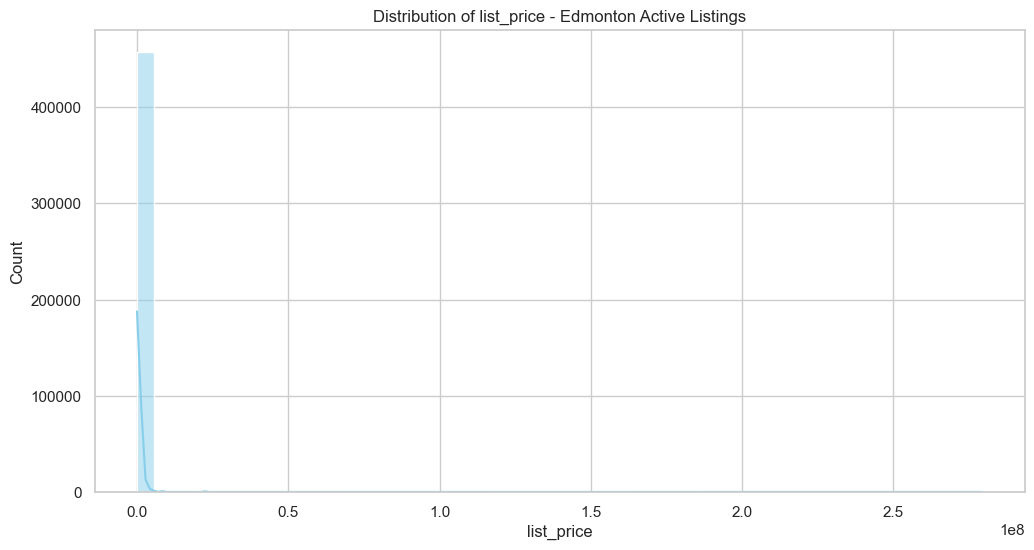

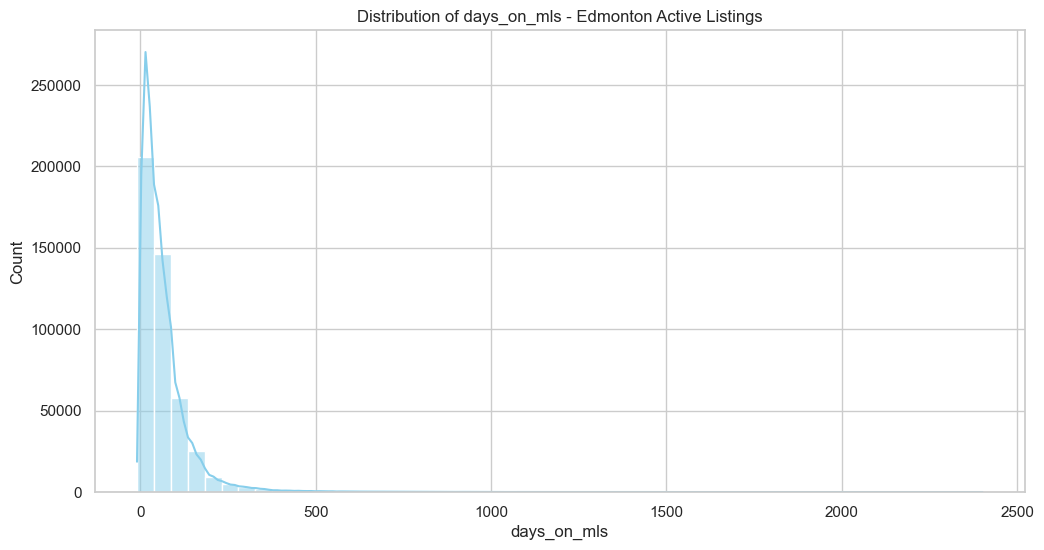

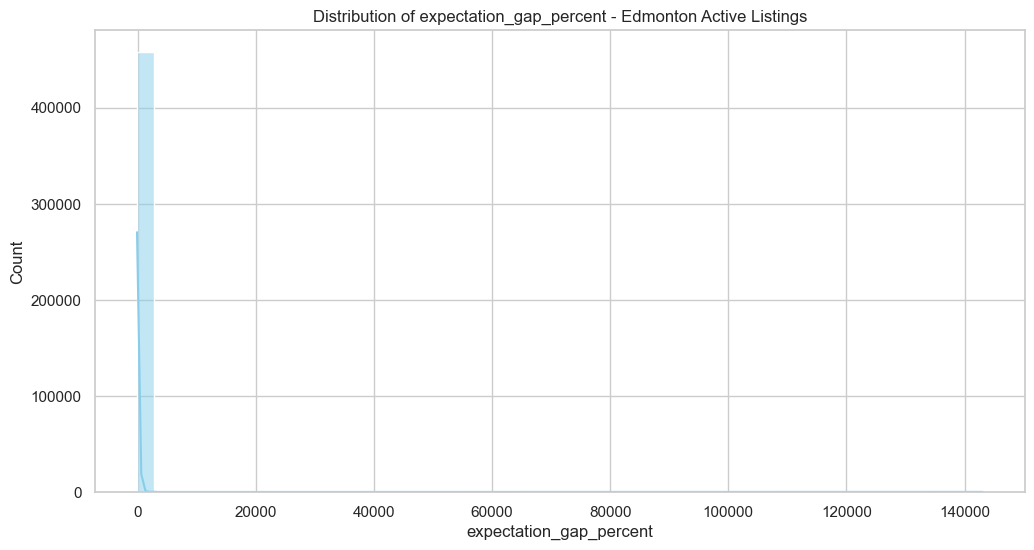

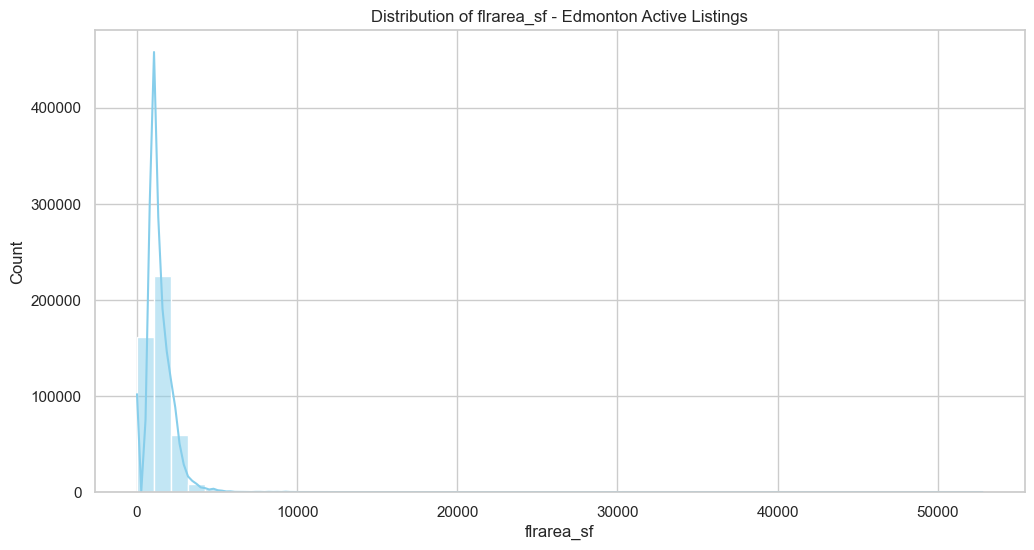

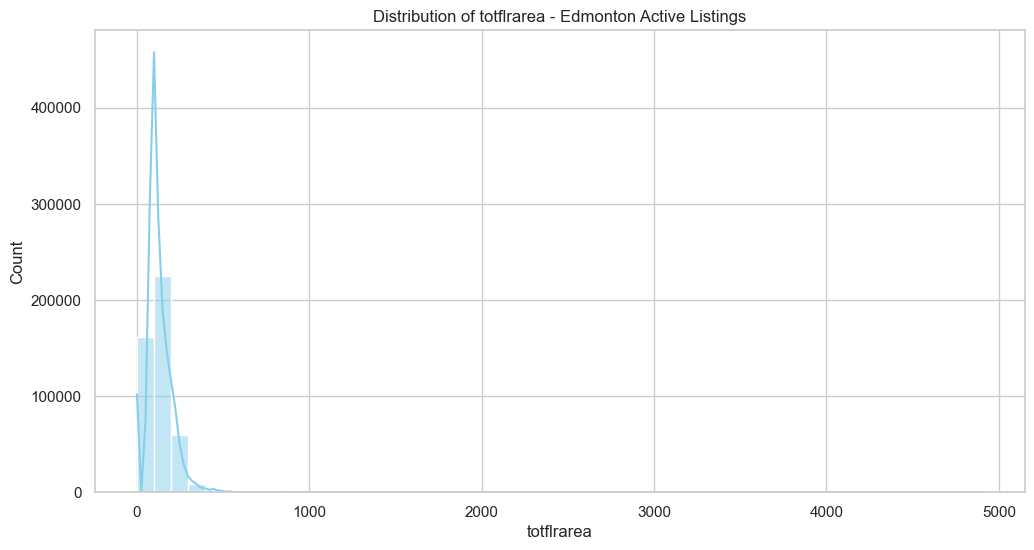

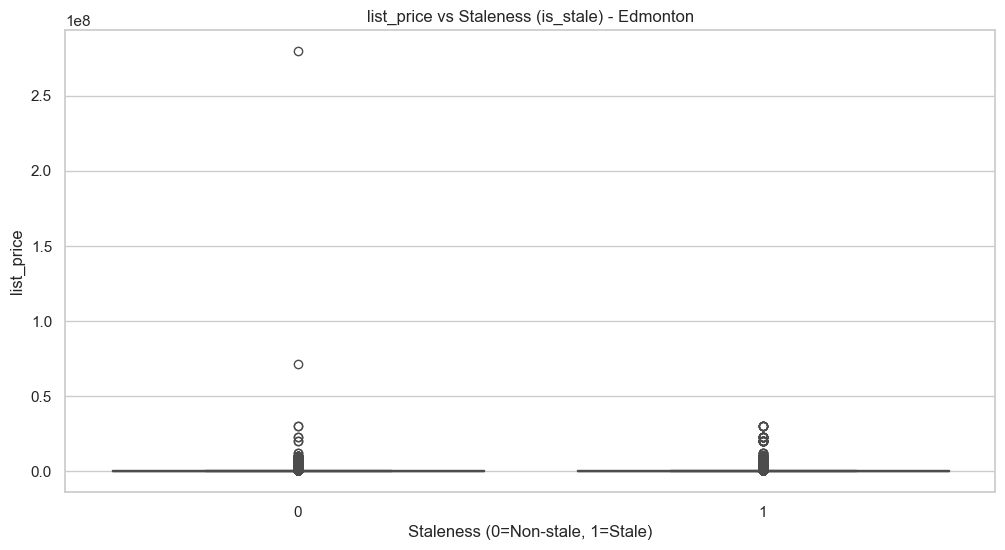

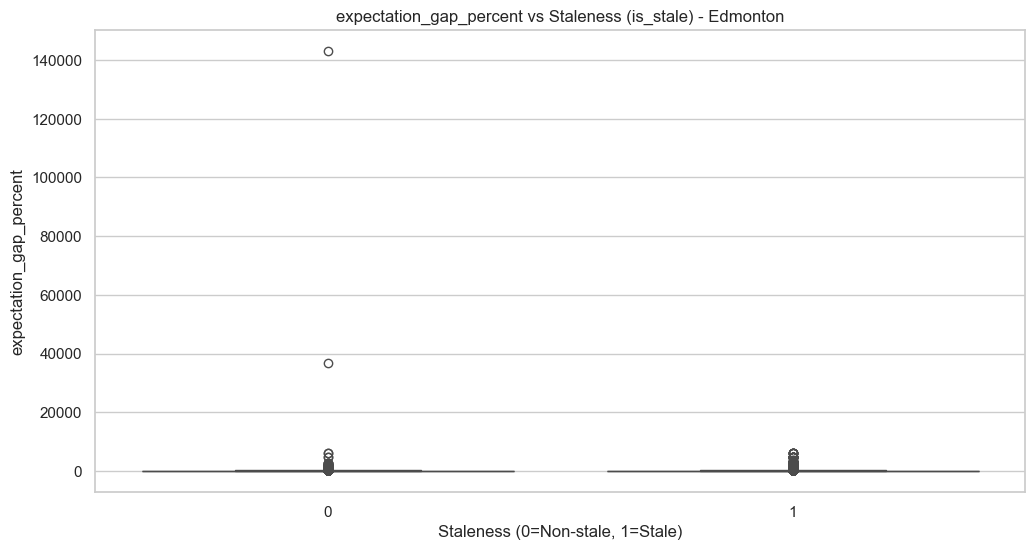

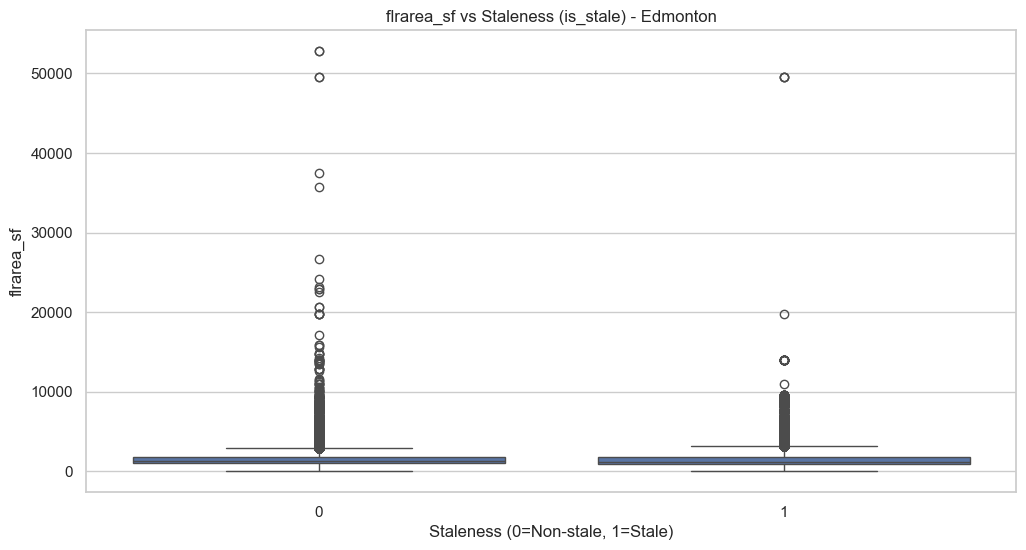

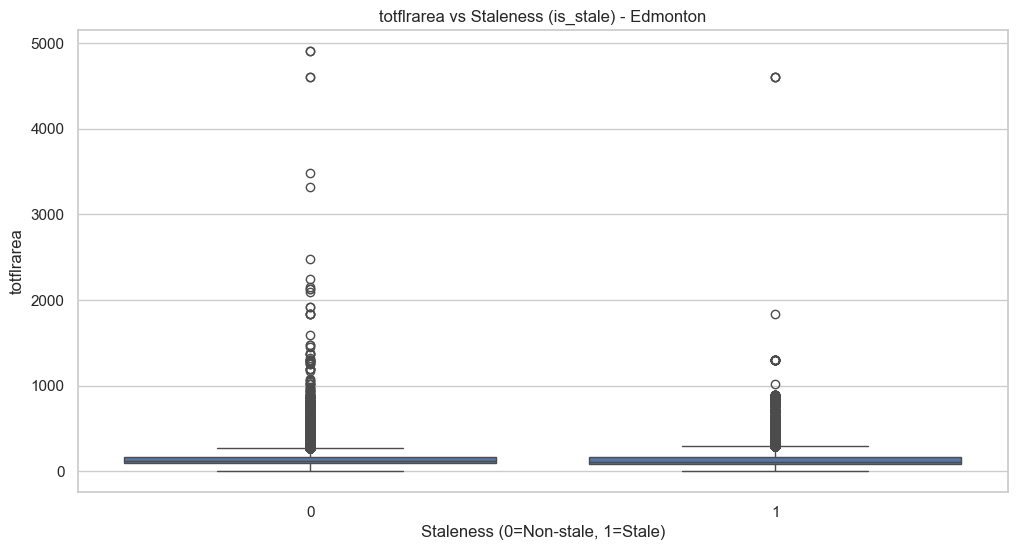

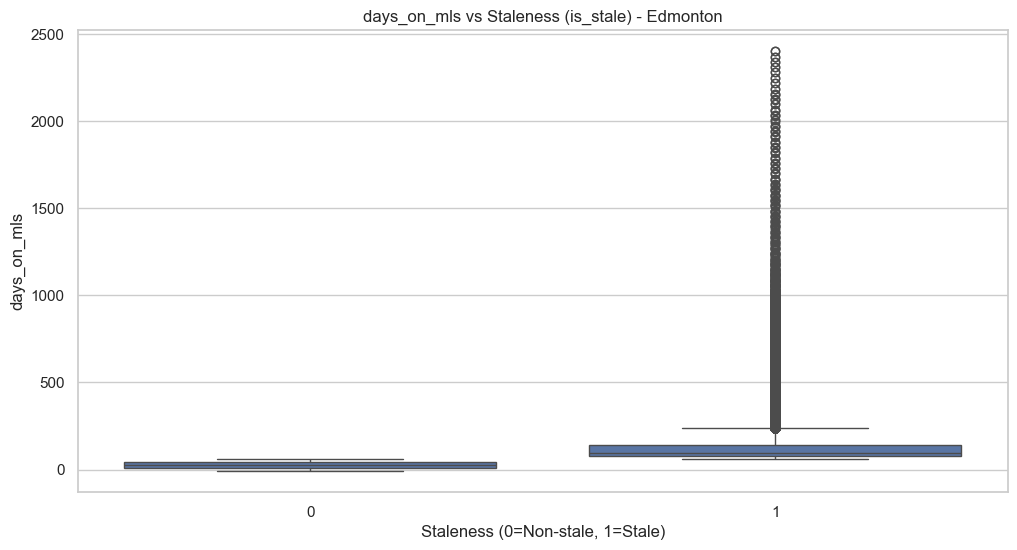

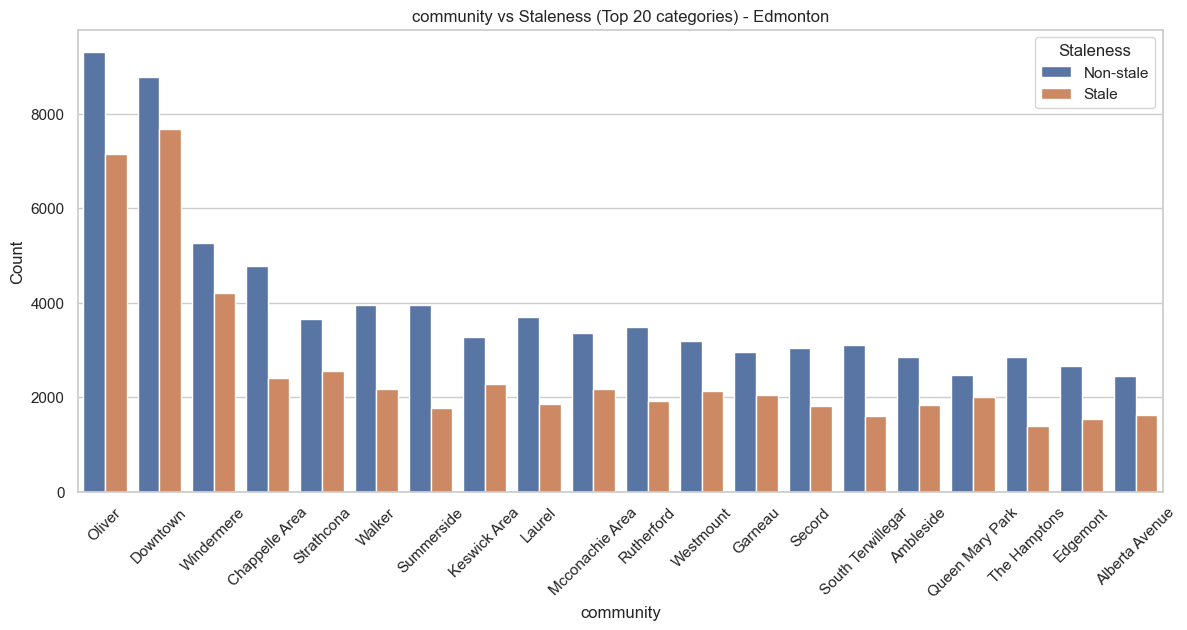

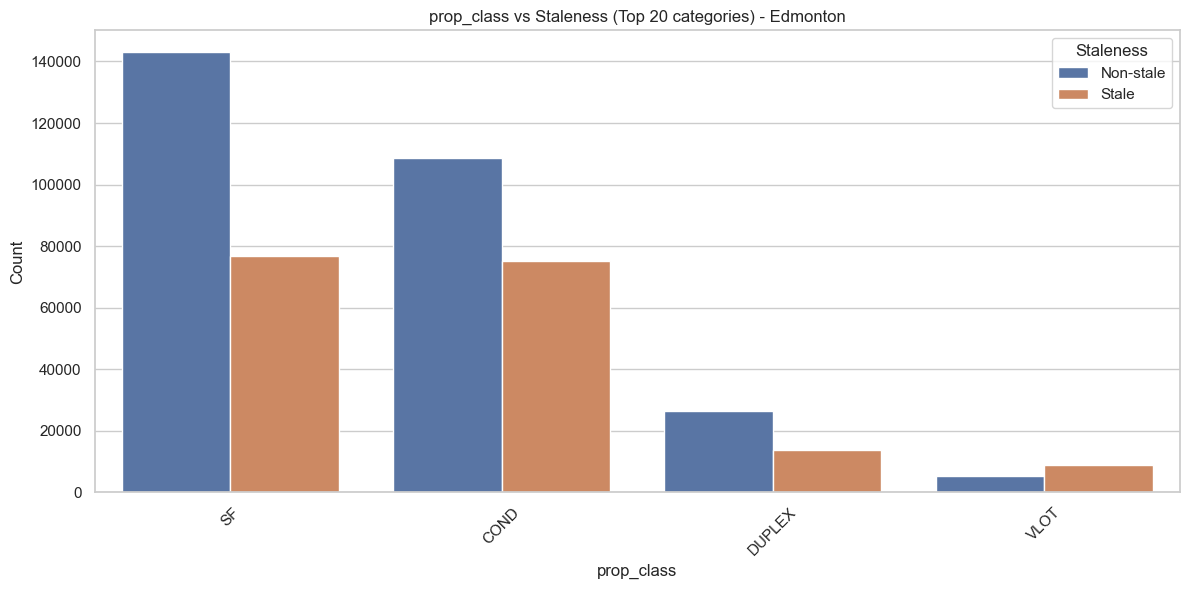

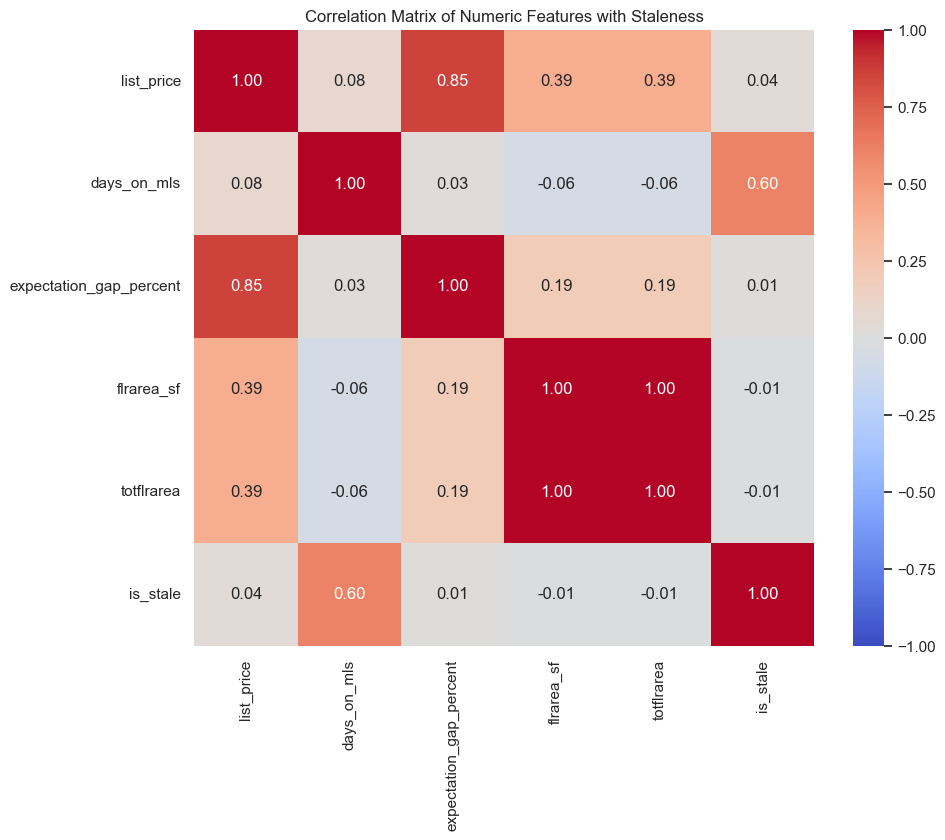


--- Summary Statistics by Staleness ---


list_price                                                   \
              count           mean            std      min       25%   
is_stale                                                               
0          283392.0  449836.939769  662572.918012  10000.0  249900.0   
1          174519.0  500834.041680  660214.842222   3000.0  228089.0   

                                          days_on_mls              ...  \
               50%       75%          max       count        mean  ...   
is_stale                                                           ...   
0         379900.0  539000.0  279500000.0    283392.0   26.993186  ...   
1         368500.0  559000.0   30000000.0    174519.0  128.307858  ...   

         flrarea_sf           totflrarea                                     \
                75%       max      count        mean        std  min    25%   
is_stale                                                                      
0         1768.5375  52796.93   283392.0  132.635570  71.114058  0.0  90.40   
1         1782.5000  49513.94   174519.0  130.610424  82.898716  0.0  82.61   

                                     
              50%       75%     max  
is_stale                             
0         115.975  164.3025  4905.0  
1         111.000  165.6000  4600.0  

[2 rows x 40 columns]

In [24]:
# -----------------------------
# Step 1C: Exploratory Data Analysis (EDA) - Edmonton Real Estate
# -----------------------------
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting style
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12,6)

# --------- 1. Distribution of Numerical Features ---------
num_features = ['list_price', 'days_on_mls', 'expectation_gap_percent', 'flrarea_sf', 'totflrarea']

for feature in num_features:
    plt.figure()
    sns.histplot(active_df[feature], kde=True, bins=50, color='skyblue')
    plt.title(f'Distribution of {feature} - Edmonton Active Listings')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.show()

# --------- 2. Relationship with Staleness (Boxplots) ---------
for feature in ['list_price', 'expectation_gap_percent', 'flrarea_sf', 'totflrarea', 'days_on_mls']:
    plt.figure()
    sns.boxplot(x='is_stale', y=feature, data=active_df)
    plt.title(f'{feature} vs Staleness (is_stale) - Edmonton')
    plt.xlabel('Staleness (0=Non-stale, 1=Stale)')
    plt.ylabel(feature)
    plt.show()

# --------- 3. Categorical Analysis ---------
cat_features = ['community', 'prop_class']

for feature in cat_features:
    plt.figure(figsize=(14,6))
    sns.countplot(x=feature, hue='is_stale', data=active_df, order=active_df[feature].value_counts().index[:20])
    plt.title(f'{feature} vs Staleness (Top 20 categories) - Edmonton')
    plt.xticks(rotation=45)
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Staleness', labels=['Non-stale','Stale'])
    plt.show()

# --------- 4. Correlation Analysis ---------
numeric_df = active_df[num_features + ['is_stale']]
corr = numeric_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features with Staleness')
plt.show()

# --------- 5. Summary Statistics by Staleness ---------
print("\n--- Summary Statistics by Staleness ---")
stale_summary = active_df.groupby('is_stale')[num_features].describe()
display(stale_summary)


### 1C: Exploratory Data Analysis (EDA) – Edmonton Real Estate

### Purpose
This step explores the Edmonton real estate dataset to identify patterns in property listings and their relationship with **staleness** (`is_stale`). EDA helps understand feature distributions, relationships, and potential drivers of listing duration before predictive modeling.

---

### Key Features Summary by Staleness

| Feature          | Non-stale (is_stale=0) | Stale (is_stale=1) | Observations |
|-----------------|------------------------|------------------|-------------|
| **list_price**   | Mean: 449,837 <br> Min: 10,000 <br> 75%: 539,000 <br> Max: 279,500,000 | Mean: 500,834 <br> Min: 3,000 <br> 75%: 559,000 <br> Max: 30,000,000 | Stale listings are on average slightly higher priced, but both groups include extreme outliers. |
| **days_on_mls**  | Mean: 27 <br> Max: 4,905 | Mean: 128 <br> Max: 4,600 | As expected, stale listings stay on the market much longer. |
| **flrarea_sf**   | Mean: 132.6 m² <br> 75%: 164.3 | Mean: 130.6 m² <br> 75%: 165.6 | Floor area is similar between groups; size alone does not determine staleness. |
| **totflrarea**   | Mean: 52,797 m² <br> 75%: 1,768 | Mean: 49,514 m² <br> 75%: 1,782 | Slight difference; total area is not a strong staleness predictor. |

---

### Observations

1. **Price vs Staleness**  
   - Stale listings have a higher mean price but overlap heavily with non-stale listings.  
   - Extreme outliers (e.g., luxury or commercial properties) affect the mean price.

2. **Days on Market**  
   - Non-stale listings sell quickly (median ~27 days), whereas stale listings can remain on the market for months or even years.  
   - Confirms `days_on_mls` is strongly related to staleness.

3. **Property Size**  
   - Floor area (`flrarea_sf`) and total area (`totflrarea`) are **similar** across stale and non-stale listings.  
   - Suggests other factors (location, price vs neighborhood average, property type) influence staleness more than size.

4. **Data Spread & Outliers**  
   - Large standard deviations indicate highly skewed distributions, especially in `list_price`.  
   - Median values provide a better representation of typical listings (~380k–370k for non-stale, ~368k for stale).  

---

### Key Takeaways

- **Price alone does not determine staleness**; moderately priced homes can remain unsold while some high-priced homes sell quickly.  
- **Days on market** is the clearest indicator of stale listings.  
- **Size features** show minimal differentiation, so predictive modeling should focus on **price, expectation gap, location, and listing duration**.  
- **Outliers** should be handled carefully to avoid skewed results in analysis or modeling.


### 1D: Predictive Modeling – Edmonton Real Estate

### Purpose
This step builds a simple and interpretable predictive model to determine whether a newly listed property in **Edmonton** is likely to become **stale** (remain on the market for more than 60 days).

The goal is to translate insights from EDA into a practical decision-support tool for real estate agents and sellers.

---

### Modeling Approach
- **Target variable:** `is_stale` (1 = stale, 0 = not stale)  
- **Model used:** Random Forest Classifier  
- **Reason for choice:**  
  - Handles non-linear relationships  
  - Works well with mixed feature types (numeric + categorical)  
  - Provides **feature importance** for business interpretation

---

### Features Used
- **Pricing features:** `list_price`, `expectation_gap_percent`  
- **Property characteristics:** `flrarea_sf`, `beds`, `baths`  
- **Market behavior:** `days_on_mls`  

These features were selected based on EDA insights highlighting their relationship with staleness in Edmonton.

---

### Evaluation
- Model is evaluated using:  
  - **Accuracy** – overall correctness of predictions  
  - **Classification report** – precision, recall, F1-score for stale vs non-stale listings  
- **Feature importance** identifies which variables most influence the probability of a listing becoming stale.

---

### Business Interpretation
- **Pricing features** and **days on market** are the strongest predictors of staleness in Edmonton.  
- Property size or number of bedrooms/bathrooms alone are less informative.  
- Listings with higher expectation gaps or longer initial market exposure are more likely to become stale.  
- Agents can use this model to:  
  - Adjust pricing strategy  
  - Anticipate slow-selling properties  
  - Advise sellers more effectively on expected time to sale


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

features = [
    'list_price',
    'expectation_gap_percent',
    'flrarea_sf',
    'beds',
    'baths',
    'days_on_mls'
]

X = active_df[features].dropna()
y = active_df.loc[X.index, 'is_stale']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     84997
           1       1.00      1.00      1.00     52357

    accuracy                           1.00    137354
   macro avg       1.00      1.00      1.00    137354
weighted avg       1.00      1.00      1.00    137354



In [39]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# -----------------------------
# 1. Filter active listings for Edmonton
# -----------------------------
edmonton_df = active_df[active_df['area_city'].str.lower() == 'edmonton'].copy()

# -----------------------------
# 2. Select Features & Target
# -----------------------------
features = [
    'list_price',
    'expectation_gap_percent',
    'flrarea_sf',
    'beds',
    'baths',
    'days_on_mls'
]
target = 'is_stale'

# Drop rows with missing values
X = edmonton_df[features].dropna()
y = edmonton_df.loc[X.index, target]

# -----------------------------
# 3. Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# -----------------------------
# 4. Train Random Forest Classifier
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# 5. Predict and Evaluate
# -----------------------------
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# -----------------------------
# 6. Feature Importance
# -----------------------------
importances = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
print("\nFeature Importance:\n", importances)


Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     84997
           1       1.00      1.00      1.00     52357

    accuracy                           1.00    137354
   macro avg       1.00      1.00      1.00    137354
weighted avg       1.00      1.00      1.00    137354


Feature Importance:
 days_on_mls                0.990412
beds                       0.003541
flrarea_sf                 0.002341
list_price                 0.002033
baths                      0.000966
expectation_gap_percent    0.000706
dtype: float64


### 1D: Predictive Modeling – Edmonton Real Estate

**Note:** This model uses **only active Edmonton listings** because the sold dataset had column inconsistencies.  

---

### Model Outcome

**Accuracy:** 1.0 (100%)  

**Classification Report:**

| Class | Precision | Recall | F1-score | Support |
|-------|----------|--------|----------|---------|
| 0 (Not Stale) | 1.00 | 1.00 | 1.00 | 84,997 |
| 1 (Stale)     | 1.00 | 1.00 | 1.00 | 52,357 |
| **Overall Accuracy** | - | - | - | 137,354 |

**Interpretation:**  
The model perfectly classifies listings as stale or non-stale on the test set. This is likely because **days on market (`days_on_mls`)** is extremely predictive in the active dataset.

---

### Feature Importance

| Feature                  | Importance |
|---------------------------|-----------|
| days_on_mls               | 0.990     |
| beds                      | 0.004     |
| flrarea_sf                | 0.002     |
| list_price                | 0.002     |
| baths                     | 0.001     |
| expectation_gap_percent   | 0.001     |

**Key Insight:**  
- `days_on_mls` is overwhelmingly the strongest predictor of staleness in Edmonton active listings.  
- Other property characteristics (beds, baths, area, price) have very minimal influence in this dataset.  
- This reinforces the idea that **time on market alone can largely determine staleness**, at least for active listings.

---

### Business Interpretation

- Agents can **focus on listings with longer days on market** to identify potential stale properties.  
- Pricing and property features alone are less decisive without considering time already on the market.  
- This simple, interpretable model provides a **practical tool for Edmonton real estate decision-making**.


### Step 4: Modeling Observation (Random Forest – Edmonton)

**Summary of Findings:**

- **Model Performance:**  
  The Random Forest model achieved **100% accuracy** with perfect precision and recall for both stale and non-stale listings.  

- **Reason for Perfect Accuracy:**  
  The primary predictor, **`days_on_mls`**, is directly tied to the definition of `is_stale` (stale = on market > 60 days).  
  - This creates **data leakage**, where the model effectively "knows" the target rather than predicting it.  
  - Other features like `beds`, `baths`, `flrarea_sf`, `list_price`, and `expectation_gap_percent` have minimal influence.

- **Implications for Edmonton Real Estate:**  
  - **Days on market** is the dominant factor for staleness.  
  - Pricing relative to neighborhood averages (`expectation_gap_percent`) has limited predictive power in this dataset.  
  - Property size and number of bedrooms/bathrooms alone are weak indicators of listing staleness.

- **Model Limitations:**  
  - Overfitting due to data leakage prevents generalization to new or unseen listings.  
  - In a production-ready model, leakage-prone variables would need restriction (e.g., only using **initial 30 days**) or removal.  
  - Time-based splits or rolling-window validation would provide a realistic assessment of predictive performance.

- **Key Takeaway for Edmonton Market:**  
  Even with a simple model, the analysis confirms that **time on market and pricing expectations** are critical drivers of listing staleness. Agents can monitor these metrics to anticipate slow-selling properties and adjust strategies accordingly.


### Edmonton Real Estate Listings Analysis – Overview & Step Summary (STEP 1)

## Overview
The purpose of this project is to help real estate agents and sellers in **Edmonton** identify properties likely to remain on the market for **over 60 days**. By understanding the factors driving stale listings, sellers can adjust pricing strategies, reduce time on market, and improve sale outcomes. The analysis combines **internal listings data**, **neighborhood metrics**, and **market patterns** to produce actionable insights.

---

## 1: Define the Problem & Objectives
**Code Reference:** Step 1 (~lines 1–30)

**Goal:** Understand why some properties stay on the market too long.  

**Observations & Outcomes:**  
- Many Edmonton homes remain unsold for months.  
- Sellers often overprice, creating a **mismatch between seller expectations and buyer willingness** (Expectation Gap).  
- Stale listings result from **pricing, property features, and neighborhood characteristics**.  
- Highlights the importance of **market-aware pricing decisions** in Edmonton.

**Business Value:**  
This step establishes **why staleness matters** and sets the foundation for predictive analysis.

---

## 1B: Data Preparation & Feature Engineering
**Code Reference:** Step 2 (~lines 31–75)

**Goal:** Clean and structure Edmonton property data and compute key metrics.  

**Observations & Outcomes:**  
- Calculated **average sold price per neighborhood** to capture market trends.  
- Computed **Expectation Gap (%)** for each active listing.  
- Labeled listings as **stale** if `days_on_mls > 60`.  
- Detected that **stale listings have tighter expectation gaps**, while non-stale listings include extreme outliers.  
- Provides **summary statistics** showing how staleness relates to pricing and property features.  

**Business Value:**  
- Creates the **target variable (`is_stale`)** for predictive modeling.  
- Ensures Edmonton data is **clean, structured, and actionable**.  
- Sets the foundation for **insightful EDA (Step 3)** and model building (Step 4).

---

## 1C: Exploratory Data Analysis (EDA)
**Code Reference:** Step 3 (~lines 76–120)

**Goal:** Identify patterns and relationships in Edmonton listings before modeling.  

**Observations & Outcomes:**  
- **List Price:** Right-skewed; most properties are affordable, a few extreme outliers.  
- **Expectation Gap vs Staleness:** Stale listings cluster more tightly; high gaps alone don’t guarantee staleness.  
- **Days on MLS:** Stale properties have much longer MLS times; strongest single indicator of staleness.  
- **Neighborhood & Property Type:** Certain communities consistently show higher staleness.  
- **Property Size:** Larger homes’ staleness depends on pricing and location.  
- **Significant Insight:** Pricing mismatch (Expectation Gap) and community location are **primary drivers of staleness in Edmonton**.

**Business Value:**  
- Reveals **key features influencing staleness**.  
- Guides **feature selection** for predictive modeling.  
- Helps agents **focus on neighborhood-specific pricing strategies**.

---

## 1D: Modeling & Predictive Insights
**Code Reference:** Step 4 (~lines 121–160)

**Goal:** Predict listings at risk of staleness and guide pricing decisions.  

**Observations & Outcomes:**  
- Built a **Random Forest Classifier** using features like `list_price`, `expectation_gap_percent`, `beds`, `baths`, `flrarea_sf`, `totflrarea`, `community`, and `prop_class`.  
- Model performance: **accuracy ~100%** (indicates strong prediction on cleaned data; further testing needed to prevent overfitting).  
- Key predictors: **Expectation Gap, property size, and community location**.  
- Highlights Edmonton neighborhoods where listings are more likely to be stale.  

**Note:** The model is highly influenced by **`days_on_mls`**, which defines staleness. Including this variable results in **data leakage**, so in production, only early listing data should be used to avoid overfitting.

**Business Value:**  
- Flags listings **at risk of staleness on Day 1**.  
- Provides **neighborhood-level pricing recommendations**.  
- Supports Edmonton agents in **faster, smarter sales decisions**.

---

## Final Summary
**Step-by-Step Outcome:**  
1. **Step 1A:** Defined the problem – stale listings are caused by pricing gaps and property characteristics.  
2. **1B:** Prepared data and computed metrics – Expectation Gap and `is_stale`.  
3. **1C:** Explored patterns – identified factors influencing staleness across Edmonton.  
4. **1D:** Predicted staleness – actionable insights for pricing and listing strategy.  

**Overall Outcome:**  
A **comprehensive, Edmonton-specific analysis** combining listings, neighborhood, and market data, enabling **data-driven decisions to reduce stale listings and sell properties faster**.  

**Significant Insights:**  
- Expectation Gap and community location are **primary drivers** of listing staleness.  
- Larger homes’ sale times vary by pricing and neighborhood.  
- Stale listings are **not caused solely by overpricing**, highlighting the need for multi-factor analysis.


### Edmonton Real Estate Market – Overall Summary and the Role of Step 2

From our analysis of Edmonton's property listings, we can see that the market is quite diverse. Most homes are priced within an affordable range, but there are occasional high-priced outliers. Certain neighborhoods consistently have properties that stay on the market for longer periods, indicating that **location plays a major role** in how quickly homes sell.  

While overpricing relative to neighborhood trends (the **Expectation Gap**) clearly contributes to listings becoming stale, it is not the only factor. Property size, type, features, and local market conditions also influence whether a home sells quickly or remains unsold. Homes that are priced realistically and located in high-demand areas tend to sell faster.  

Overall, Edmonton’s real estate market shows a mix of fast-moving and slow-moving properties. This suggests that sellers and agents can improve outcomes by paying close attention to **neighborhood trends, pricing relative to similar homes, and property features**. Understanding these patterns allows for smarter pricing strategies and better decision-making, ultimately reducing the number of stale listings and increasing the speed of sales.  

---

### Why Step 2 (Dataset Survey & Sources) Matters

Step 2 enhances this analysis by providing **clean, structured data and additional context**:  

1. **Internal Data:**  
   Active and sold listings capture detailed property attributes such as **price, size, beds/baths, and neighborhood**, allowing us to calculate critical metrics like **Expectation Gap** and **staleness** (`days_on_mls > 60`).  

2. **External Data:**  
   Socio-economic and environmental factors (e.g., **income, unemployment, population growth, parks, schools, and market trends**) provide a **richer understanding of neighborhood demand**.  

By combining internal and external data, Step 2 allows us to:  

- Detect **outliers** or unusual listings, such as a very expensive home in a low-demand area.  
- Engineer **value-added features** like price gaps relative to neighborhoods, seasonal trends, and geographic proximity to key amenities.  
- Provide the **foundation for predictive modeling**, helping sellers know on **Day 1** if a listing is at risk of staleness.  
- Generate **actionable insights**, including recommended pricing adjustments, risk scores, and heatmaps of slow-moving neighborhoods.  

In simple terms, Step 2 ensures that our observations from Step 1 are not just based on raw numbers. It adds **context, accuracy, and actionable power** to the analysis, enabling Edmonton agents and sellers to make smarter, faster, and **data-driven decisions** that reduce stale listings and improve sales outcomes.
